# 1. import

In [3]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

# 2. Config

In [4]:
ROOT = Path(
    "/Users/mac/Detect_Drill_Bit/data_convert_yolo_format"
)


CLASS_NAMES = {
    0:"Broken",
    1:"Chipped",
    2:"Scratched",
    3:"Severe_Rust",
    4:"Tip_Wear"
}


IMG_EXT = [
    ".jpg",
    ".jpeg",
    ".png"
]

# 3. Dataset Summary

In [5]:
def count_dataset(split):

    img_dir = split / "images"
    label_dir = split / "labels"

    images = [
        x for x in img_dir.iterdir()
        if x.suffix.lower() in IMG_EXT
    ]

    labels = list(label_dir.glob("*.txt"))

    return len(images), len(labels)



for split in [
    ROOT/"train",
    ROOT/"valid"
]:

    imgs, labels = count_dataset(split)

    print(
        split.name,
        ":",
        imgs,
        "images |",
        labels,
        "labels"
    )


# test

test_images = 0
test_labels = 0


for folder in [
    ROOT/"test/Bright_Field",
    ROOT/"test/Dark_Field"
]:

    imgs, labels = count_dataset(folder)

    test_images += imgs
    test_labels += labels


print(
    "test :",
    test_images,
    "images |",
    test_labels,
    "labels"
)

train : 4364 images | 3597 labels
valid : 844 images | 706 labels
test : 704 images | 1094 labels


# 4. Class Distribution

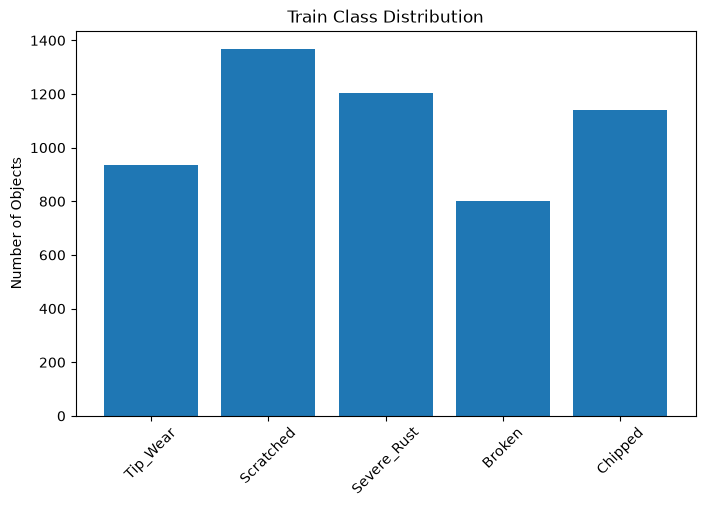

In [6]:
def get_classes(label_dir):

    counter = Counter()


    for txt in label_dir.glob("*.txt"):

        with open(txt) as f:

            for line in f:

                cls = int(
                    line.split()[0]
                )

                counter[cls]+=1


    return counter



train_class = get_classes(
    ROOT/"train/labels"
)


plt.figure(figsize=(8,5))


plt.bar(
    [
        CLASS_NAMES[x]
        for x in train_class.keys()
    ],
    train_class.values()
)


plt.xticks(rotation=45)

plt.title(
    "Train Class Distribution"
)

plt.ylabel(
    "Number of Objects"
)

plt.show()

# 5. Objects per Image

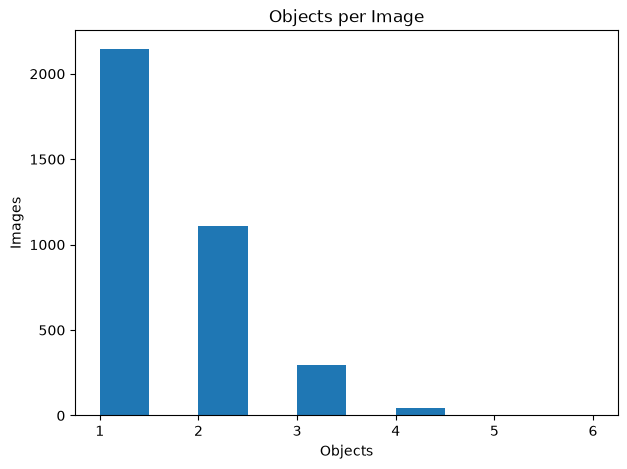

In [7]:
objects=[]


for txt in (ROOT/"train/labels").glob("*.txt"):

    with open(txt) as f:

        objects.append(
            len(f.readlines())
        )


plt.figure(figsize=(7,5))


plt.hist(
    objects,
    bins=10
)


plt.title(
    "Objects per Image"
)


plt.xlabel(
    "Objects"
)


plt.ylabel(
    "Images"
)


plt.show()

# 6. Bounding Box Size Distribution

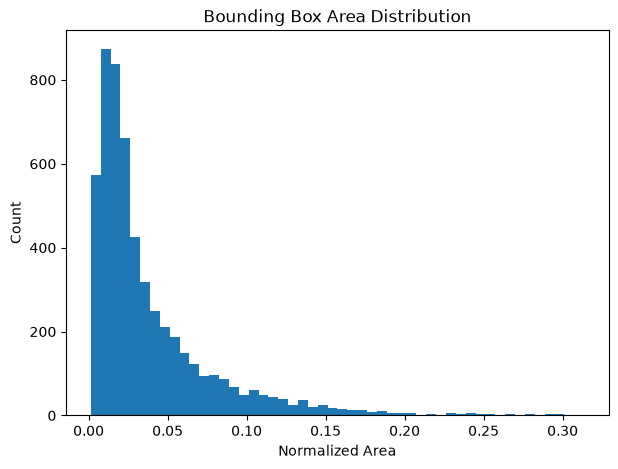

In [8]:
widths=[]
heights=[]
areas=[]


for txt in (ROOT/"train/labels").glob("*.txt"):

    with open(txt) as f:

        for line in f:

            data=line.split()

            w=float(data[3])
            h=float(data[4])


            widths.append(w)
            heights.append(h)

            areas.append(w*h)



plt.figure(figsize=(7,5))

plt.hist(
    areas,
    bins=50
)


plt.title(
    "Bounding Box Area Distribution"
)


plt.xlabel(
    "Normalized Area"
)


plt.ylabel(
    "Count"
)


plt.show()

# 7. Width / Height Ratio

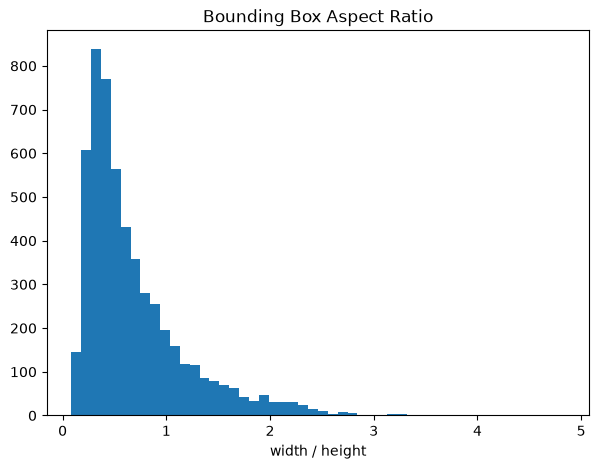

In [9]:
ratios=[]


for w,h in zip(widths,heights):

    ratios.append(
        w/h
    )


plt.figure(figsize=(7,5))


plt.hist(
    ratios,
    bins=50
)


plt.title(
    "Bounding Box Aspect Ratio"
)


plt.xlabel(
    "width / height"
)


plt.show()

# 8. Bounding Box Heatmap

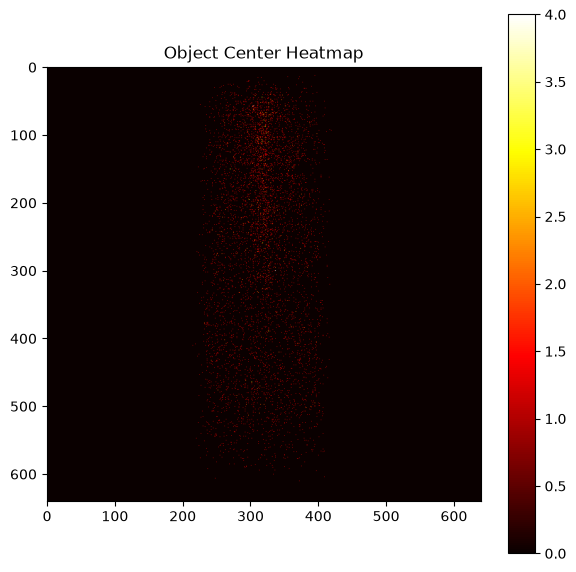

In [10]:
heatmap = np.zeros(
    (640,640)
)


for txt in (ROOT/"train/labels").glob("*.txt"):


    with open(txt) as f:

        for line in f:

            data=line.split()


            x=float(data[1])
            y=float(data[2])


            x=int(x*640)
            y=int(y*640)


            heatmap[y,x]+=1



plt.figure(figsize=(7,7))


plt.imshow(
    heatmap,
    cmap="hot"
)


plt.colorbar()


plt.title(
    "Object Center Heatmap"
)


plt.show()

# 9. Visualize Random Images + Bounding Box

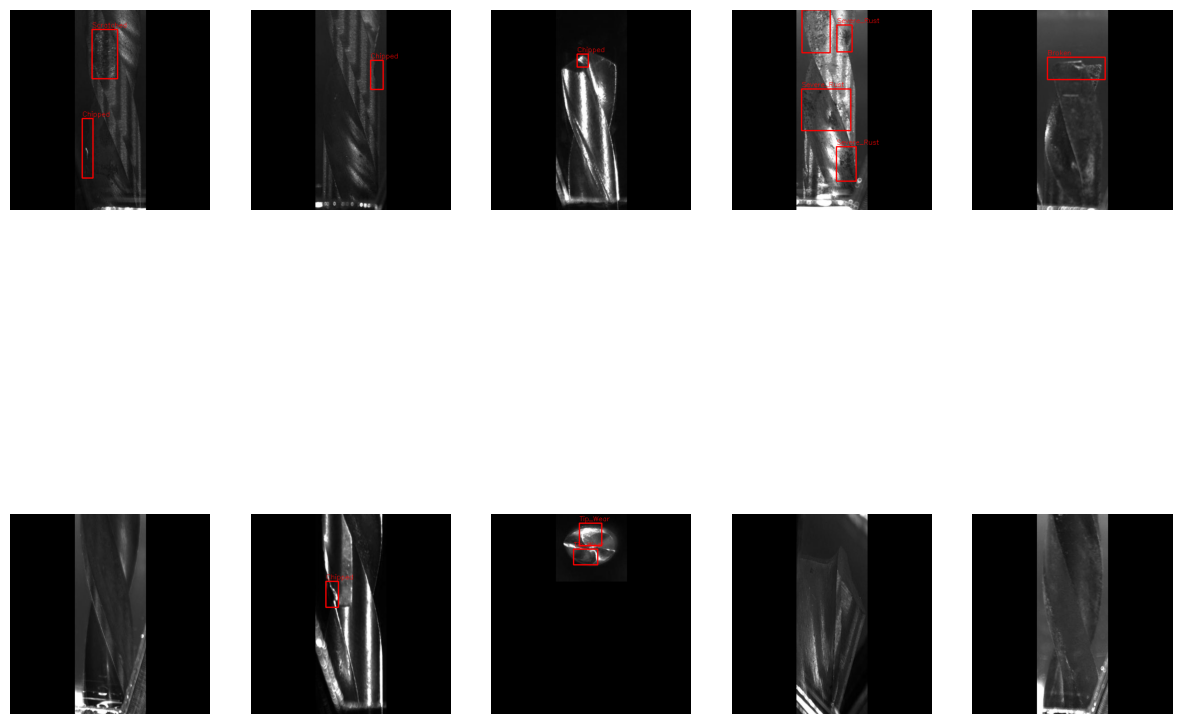

In [11]:
def visualize_samples(
    n=10
):

    img_dir = ROOT/"train/images"
    label_dir = ROOT/"train/labels"


    imgs=list(img_dir.glob("*"))


    samples=random.sample(
        imgs,
        n
    )


    plt.figure(
        figsize=(15,12)
    )


    for i,img_path in enumerate(samples):

        img=cv2.imread(
            str(img_path)
        )


        img=cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )


        h,w,_=img.shape


        label_path = (
            label_dir /
            (img_path.stem+".txt")
        )


        if label_path.exists():

            with open(label_path) as f:

                for line in f:

                    cls,x,y,bw,bh=map(
                        float,
                        line.split()
                    )


                    x1=int(
                        (x-bw/2)*w
                    )

                    y1=int(
                        (y-bh/2)*h
                    )


                    x2=int(
                        (x+bw/2)*w
                    )

                    y2=int(
                        (y+bh/2)*h
                    )


                    cv2.rectangle(
                        img,
                        (x1,y1),
                        (x2,y2),
                        (255,0,0),
                        2
                    )


                    cv2.putText(
                        img,
                        CLASS_NAMES[int(cls)],
                        (x1,y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (255,0,0),
                        1
                    )


        plt.subplot(
            2,
            5,
            i+1
        )

        plt.imshow(img)

        plt.axis("off")


    plt.show()



visualize_samples(10)

# 10. Kiểm tra label lỗi

In [12]:
def check_invalid_labels():

    errors=[]


    for txt in (ROOT/"train/labels").glob("*.txt"):

        with open(txt) as f:

            for line in f:

                cls,x,y,w,h=map(
                    float,
                    line.split()
                )


                if cls>=5:
                    errors.append(
                        txt.name
                    )


                if not(
                    0<=x<=1 and
                    0<=y<=1 and
                    0<w<=1 and
                    0<h<=1
                ):
                    errors.append(
                        txt.name
                    )


    return errors



errors = check_invalid_labels()


print(
    "Invalid labels:",
    len(errors)
)

Invalid labels: 0
